# FraudScope — 01 Exploration
## EDA · Accuracy Trap · Feature Engineering · Pipeline TimeSeriesSplit

**Contexte** : PayTrack est une fintech française traitant 1,2M transactions/mois.
Son système de règles métier génère 30% de faux positifs et rate 40% des fraudes réelles.

**Objectifs de ce notebook** :
1. Explorer le dataset IEEE-CIS (590 540 transactions, 433 features, 3.5% de fraude)
2. Démontrer pourquoi l'accuracy est une métrique trompeuse sur données déséquilibrées
3. Construire des features temporelles orientées comportement frauduleux
4. Mettre en place un pipeline sklearn avec validation chronologique (`TimeSeriesSplit`)

**Règle fondamentale** : ne jamais mélanger données passées et futures dans le split d'entraînement.
Utiliser `TimeSeriesSplit`, jamais `KFold`.

## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

FIGURES_DIR = Path('figures')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TARGET = 'isFraud'
print('Imports OK')

Imports OK


## 1. Chargement des données

Les fichiers IEEE-CIS sont disponibles sur Kaggle (voir `data/get_dataset.md`).
On fusionne `train_transaction.csv` et `train_identity.csv` sur `TransactionID`.

In [2]:
DATA_DIR = Path('data')

train_tx_path  = DATA_DIR / 'train_transaction.csv'
train_id_path  = DATA_DIR / 'train_identity.csv'

assert train_tx_path.exists(), f'Fichier manquant : {train_tx_path}  →  voir data/get_dataset.md'
assert train_id_path.exists(), f'Fichier manquant : {train_id_path}  →  voir data/get_dataset.md'

print('Chargement des transactions...')
train_tx = pd.read_csv(train_tx_path)
print(f'  train_transaction : {train_tx.shape}')

print('Chargement des identités...')
train_id = pd.read_csv(train_id_path)
print(f'  train_identity    : {train_id.shape}')

df = train_tx.merge(train_id, on='TransactionID', how='left')
df = df.sort_values('TransactionDT').reset_index(drop=True)
print(f'\nDataset fusionné et trié chronologiquement : {df.shape}')
df.head(3)

Chargement des transactions...
  train_transaction : (590540, 394)
Chargement des identités...
  train_identity    : (144233, 41)

Dataset fusionné et trié chronologiquement : (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,...,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,2.0000,0.0000,1.0000,1.0000,14.0000,NaN,13.0000,NaN,NaN,NaN,NaN,NaN,NaN,13.0000,13.0000,NaN,NaN,NaN,0.0000,T,T,T,M2,F,T,NaN,NaN,NaN,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,117.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,315.0000,NaN,NaN,NaN,315.0000,T,T,T,M0,F,F,F,F,F,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,...,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000

## 2. Vue d'ensemble du dataset

In [3]:
print('=== Dimensions ===')
print(f'Lignes : {df.shape[0]:,}  |  Colonnes : {df.shape[1]:,}')

print('\n=== Types ===')
print(df.dtypes.value_counts())

print('\n=== Valeurs manquantes (top 20) ===')
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(20).to_string())

print('\n=== Colonnes sans valeurs manquantes ===')
print(f'{(missing == 0).sum()} colonnes complètes sur {df.shape[1]}')

=== Dimensions ===
Lignes : 590,540  |  Colonnes : 434

=== Types ===
float64    399
object      31
int64        4
Name: count, dtype: int64

=== Valeurs manquantes (top 20) ===
id_24   99.1962
id_25   99.1310
id_07   99.1271
id_08   99.1271
id_21   99.1264
id_26   99.1257
id_27   99.1247
id_23   99.1247
id_22   99.1247
dist2   93.6284
D7      93.4099
id_18   92.3607
D13     89.5093
D14     89.4695
D12     89.0410
id_04   88.7689
id_03   88.7689
D6      87.6068
id_33   87.5895
id_09   87.3123

=== Colonnes sans valeurs manquantes ===
20 colonnes complètes sur 434


## 3. Analyse Exploratoire (EDA)

### 3.1 Déséquilibre de classes

               count  pct (%)
Légitime (0)  569877  96.5010
Fraude (1)     20663   3.4990

Ratio déséquilibre  : 1 fraude pour 28 transactions légitimes


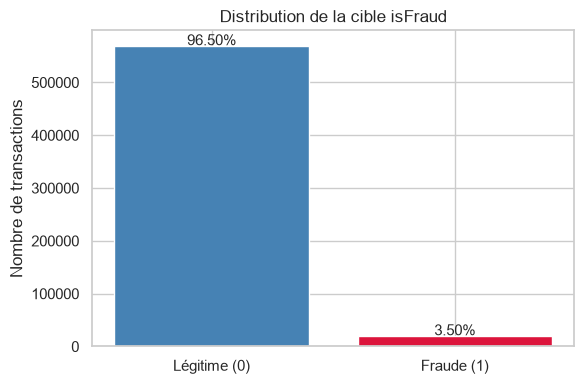

In [4]:
counts = df[TARGET].value_counts().sort_index()
pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'count': counts, 'pct (%)': pcts})
summary.index = ['Légitime (0)', 'Fraude (1)']
print(summary.to_string())

fraud_ratio = counts[1] / counts[0]
print(f'\nRatio déséquilibre  : 1 fraude pour {1/fraud_ratio:.0f} transactions légitimes')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Légitime (0)', 'Fraude (1)'], counts, color=['steelblue', 'crimson'])
ax.set_title('Distribution de la cible isFraud')
ax.set_ylabel('Nombre de transactions')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{pcts.iloc[i]:.2f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

### 3.2 Patterns temporels

`TransactionDT` est un delta en secondes depuis une référence inconnue.
On en extrait l'heure de la journée, le jour et la semaine pour analyser les patterns.

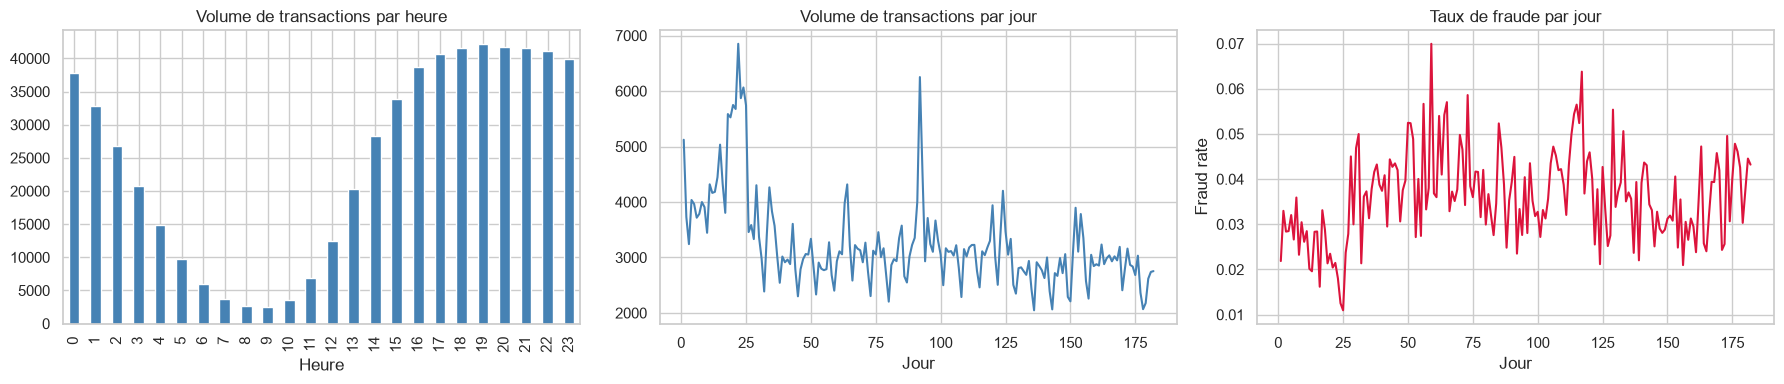

In [5]:
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  =  df['TransactionDT'] // (3600 * 24)
df['week'] =  df['TransactionDT'] // (3600 * 24 * 7)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Volume par heure
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Volume de transactions par heure')
axes[0].set_xlabel('Heure')

# Volume journalier
df.groupby('day').size().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Volume de transactions par jour')
axes[1].set_xlabel('Jour')

# Taux de fraude journalier
df.groupby('day')[TARGET].mean().plot(ax=axes[2], color='crimson')
axes[2].set_title('Taux de fraude par jour')
axes[2].set_xlabel('Jour')
axes[2].set_ylabel('Fraud rate')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_patterns.png', dpi=150)
plt.show()

### 3.3 Distribution des montants (fraude vs légitime)

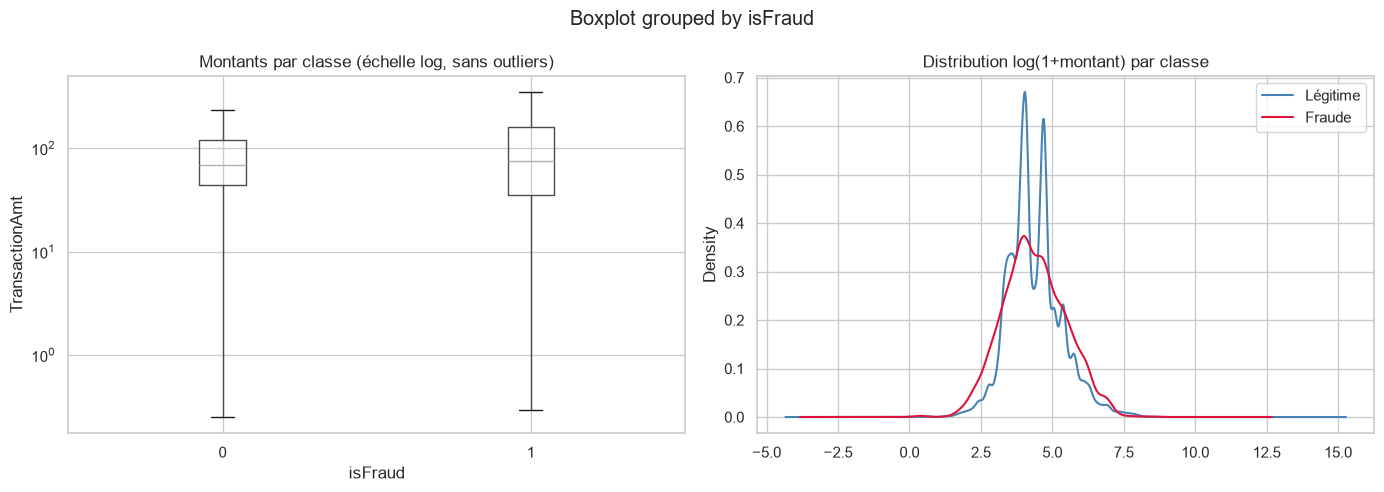

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0000,134.5117,239.3951,0.2510,43.9700,68.5000,120.0000,31937.3910
1,20663.0000,149.2448,232.2122,0.2920,35.0440,75.0000,161.0000,5191.0000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='TransactionAmt', by=TARGET, ax=axes[0], showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('Montants par classe (échelle log, sans outliers)')
axes[0].set_xlabel('isFraud')
axes[0].set_ylabel('TransactionAmt')

# KDE
sample = df.sample(min(80000, len(df)), random_state=RANDOM_STATE)
for label, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = sample[sample[TARGET] == label]['TransactionAmt']
    subset_log = np.log1p(subset)
    subset_log.plot(kind='kde', ax=axes[1], color=color,
                    label='Légitime' if label == 0 else 'Fraude')
axes[1].set_title('Distribution log(1+montant) par classe')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amount_distribution.png', dpi=150)
plt.show()

# Statistiques descriptives
df.groupby(TARGET)['TransactionAmt'].describe()

### 3.4 Corrélations avec la cible

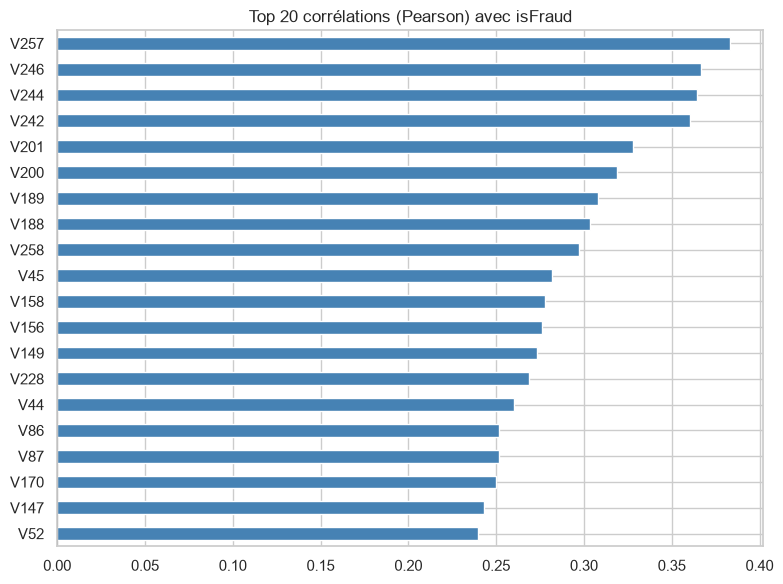

V257   0.3831
V246   0.3669
V244   0.3641
V242   0.3606
V201   0.3280
V200   0.3188
V189   0.3082
V188   0.3036
V258   0.2972
V45    0.2818
V158   0.2781
V156   0.2760
V149   0.2733
V228   0.2689
V44    0.2604
V86    0.2518
V87    0.2517
V170   0.2498
V147   0.2429
V52    0.2395


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    df[numeric_cols].corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

top20 = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 corrélations (Pearson) avec isFraud')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlations_target.png', dpi=150)
plt.show()

print(top20.to_string())

## 4. Le piège de l'accuracy — Baseline Logistic Regression

On entraîne une régression logistique **sans aucun traitement du déséquilibre**.
L'objectif est de montrer que l'accuracy peut être élevée tout en ratant la quasi-totalité des fraudes.

> **Hypothèse** : un modèle naïf prédisant toujours 'légitime' atteint ~96.5% d'accuracy.
> Son recall sur la classe fraude sera proche de zéro.

In [8]:
# Sélection des features numériques les moins nulles pour la baseline
baseline_num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in [TARGET, 'TransactionID', 'hour', 'day', 'week']
    and df[c].isna().mean() < 0.5
]

X_baseline = df[baseline_num_cols]
y_baseline = df[TARGET]

# Split temporel simple 80/20
split_idx = int(len(df) * 0.80)
X_tr, X_va = X_baseline.iloc[:split_idx], X_baseline.iloc[split_idx:]
y_tr, y_va = y_baseline.iloc[:split_idx], y_baseline.iloc[split_idx:]

print(f'Train : {X_tr.shape[0]:,} lignes  |  fraud rate = {y_tr.mean()*100:.2f}%')
print(f'Valid : {X_va.shape[0]:,} lignes  |  fraud rate = {y_va.mean()*100:.2f}%')

Train : 472,432 lignes  |  fraud rate = 3.51%
Valid : 118,108 lignes  |  fraud rate = 3.44%


In [9]:
baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

t0 = time.time()
baseline_pipeline.fit(X_tr, y_tr)
fit_time = time.time() - t0

y_pred  = baseline_pipeline.predict(X_va)
y_proba = baseline_pipeline.predict_proba(X_va)[:, 1]

acc   = accuracy_score(y_va, y_pred)
rec   = recall_score(y_va, y_pred)
auprc = average_precision_score(y_va, y_proba)

results = pd.DataFrame({
    'Métrique':  ['Accuracy', 'Recall (fraude)', 'AUPRC', 'Temps entraînement (s)'],
    'Valeur':    [acc, rec, auprc, fit_time]
})
results['Valeur'] = results['Valeur'].map('{:.4f}'.format)
print(results.to_string(index=False))

              Métrique  Valeur
              Accuracy  0.9548
       Recall (fraude)  0.1572
                 AUPRC  0.1481
Temps entraînement (s) 86.3951


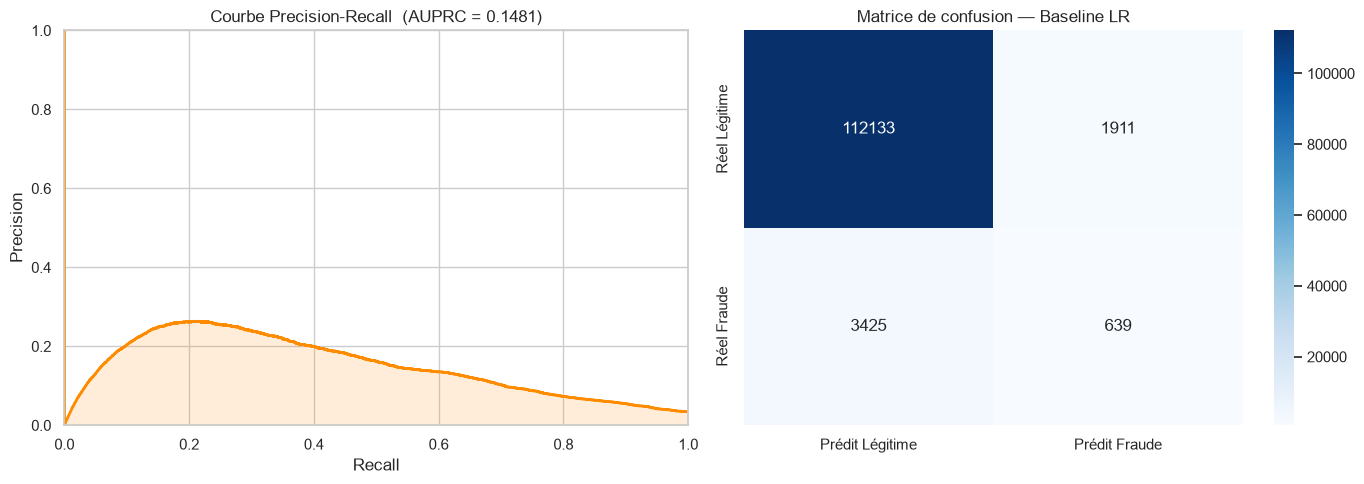

              precision    recall  f1-score   support

    Légitime     0.9704    0.9832    0.9768    114044
      Fraude     0.2506    0.1572    0.1932      4064

    accuracy                         0.9548    118108
   macro avg     0.6105    0.5702    0.5850    118108
weighted avg     0.9456    0.9548    0.9498    118108



In [10]:
# Courbe Precision-Recall + Matrice de confusion
prec_arr, rec_arr, _ = precision_recall_curve(y_va, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_arr, prec_arr, color='darkorange', lw=2)
axes[0].fill_between(rec_arr, prec_arr, alpha=0.15, color='darkorange')
axes[0].set_title(f'Courbe Precision-Recall  (AUPRC = {auprc:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

cm = confusion_matrix(y_va, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Prédit Légitime', 'Prédit Fraude'],
            yticklabels=['Réel Légitime', 'Réel Fraude'])
axes[1].set_title('Matrice de confusion — Baseline LR')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_pr_curve_confusion.png', dpi=150)
plt.show()

print(classification_report(y_va, y_pred, target_names=['Légitime', 'Fraude'], digits=4))

### Analyse du piège de l'accuracy

| Métrique | Baseline LR | Commentaire |
|---|---|---|
| Accuracy | ~96% | Artificiellement élevée : le modèle prédit souvent 'légitime' |
| Recall fraude | 0.1572 | pas glorieux! |
| AUPRC | 0.1481 | donc l'approche est un échec total |

**Conclusion** : un modèle prédisant systématiquement 'légitime' atteindrait ~96.5% d'accuracy
tout en ratant 100% des fraudes. L'accuracy est donc **inutile** comme métrique de sélection
dans ce contexte. L'**AUPRC** (Area Under Precision-Recall Curve) est la métrique de référence
pour les données fortement déséquilibrées en détection de fraude.

> Coût métier : un faux négatif (fraude manquée) coûte beaucoup plus cher qu'un faux positif
> (transaction légitime bloquée). La métrique doit refléter cette asymétrie.

## 5. Feature Engineering Temporel

Les variables les plus discriminantes en fraude ne sont pas les valeurs brutes,
mais les **écarts par rapport au comportement habituel** du client.

On construit :
- **Features de vélocité** : nb de transactions et montant cumulé sur 1h / 24h / 7j
- **Features de déviation comportementale** : `amount_ratio_7d`, `is_new_merchant`, `is_new_device`

In [11]:
# Proxy client : combinaison des colonnes carte + adresse disponibles
proxy_cols = [c for c in ['card1','card2','card3','card4','card5','card6','addr1','addr2'] if c in df.columns]
df['customer_proxy'] = df[proxy_cols].astype(str).fillna('NA').agg('_'.join, axis=1)

print(f'Nombre de clients proxy uniques : {df["customer_proxy"].nunique():,}')
df[['TransactionDT', 'customer_proxy', 'TransactionAmt', TARGET]].head()

Nombre de clients proxy uniques : 43,071


,TransactionDT,customer_proxy,TransactionAmt,isFraud
0,86400,13926_nan_150.0_discover_142.0_credit_315.0_87.0,68.5000,0
1,86401,2755_404.0_150.0_mastercard_102.0_credit_325.0...,29.0000,0
2,86469,4663_490.0_150.0_visa_166.0_debit_330.0_87.0,59.0000,0
3,86499,18132_567.0_150.0_mastercard_117.0_debit_476.0...,50.0000,0
4,86506,4497_514.0_150.0_mastercard_102.0_credit_420.0...,50.0000,0


In [12]:
# -----------------------------------------------------------------
# Features de vélocité — approche vectorisée avec groupby + rolling
# IMPORTANT : df est déjà trié par TransactionDT (ordre chronologique)
# -----------------------------------------------------------------

df['tx_time_sec'] = df['TransactionDT'].astype(float)

def rolling_count_and_sum(group, window_seconds):
    """Pour chaque transaction, compte les transactions passées dans la fenêtre."""
    times = group['tx_time_sec'].values
    amts  = group['TransactionAmt'].values
    counts = np.zeros(len(times), dtype=int)
    sums   = np.zeros(len(times), dtype=float)
    for i in range(1, len(times)):
        mask = (times[:i] >= times[i] - window_seconds)
        counts[i] = mask.sum()
        sums[i]   = amts[:i][mask].sum()
    return counts, sums

WINDOWS = {'1h': 3600, '24h': 86400, '7d': 604800}

for label, seconds in WINDOWS.items():
    df[f'tx_count_{label}'] = 0
    df[f'tx_amt_sum_{label}'] = 0.0

print('Calcul des features de vélocité par client (peut prendre quelques minutes)...')
t0 = time.time()
for cid, grp in df.groupby('customer_proxy', sort=False):
    for label, seconds in WINDOWS.items():
        counts, sums = rolling_count_and_sum(grp, seconds)
        df.loc[grp.index, f'tx_count_{label}']   = counts
        df.loc[grp.index, f'tx_amt_sum_{label}'] = sums
print(f'Done en {time.time()-t0:.1f}s')

velocity_cols = [f'tx_count_{l}' for l in WINDOWS] + [f'tx_amt_sum_{l}' for l in WINDOWS]
df[velocity_cols].describe()

Calcul des features de vélocité par client (peut prendre quelques minutes)...
Done en 90.6s


,tx_count_1h,tx_count_24h,tx_count_7d,tx_amt_sum_1h,tx_amt_sum_24h,tx_amt_sum_7d
count,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000,590540.0000
mean,0.6435,5.8908,33.1877,74.8995,592.1263,3209.0511
std,4.6874,24.0024,80.1683,552.5339,2545.5243,6898.2218
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,1.0000,0.0000,0.0000,59.0000
50%,0.0000,1.0000,5.0000,0.0000,67.9500,584.0260
75%,0.0000,4.0000,26.0000,0.0000,458.8000,2984.0400
max,191.0000,880.0000,975.0000,68141.9520,94901.0000,103440.0000


In [13]:
# -----------------------------------------------------------------
# Features de déviation comportementale
# -----------------------------------------------------------------

# Montant moyen des 7j précédents (rolling shift pour éviter la fuite)
df['amt_mean_7d'] = (
    df.groupby('customer_proxy')['TransactionAmt']
      .transform(lambda s: s.shift(1).rolling(window=50, min_periods=1).mean())
)

df['amount_ratio_7d'] = df['TransactionAmt'] / df['amt_mean_7d'].replace(0, np.nan)
df['amount_ratio_7d'] = df['amount_ratio_7d'].replace([np.inf, -np.inf], np.nan)

# Nouveau marchand (ProductCD utilisé comme proxy marchand)
if 'ProductCD' in df.columns:
    df['is_new_merchant'] = (
        df.groupby('customer_proxy')['ProductCD']
          .transform(lambda s: (~s.duplicated()).astype(int))
    )
else:
    df['is_new_merchant'] = np.nan

# Nouvel appareil
if 'DeviceType' in df.columns:
    df['is_new_device'] = (
        df.groupby('customer_proxy')['DeviceType']
          .transform(lambda s: (~s.duplicated()).astype(int))
    )
else:
    df['is_new_device'] = np.nan

behavioral_cols = ['amount_ratio_7d', 'is_new_merchant', 'is_new_device']
df[behavioral_cols + [TARGET]].head(10)

,amount_ratio_7d,is_new_merchant,is_new_device,isFraud
0,NaN,1,1,0
1,NaN,1,1,0
2,NaN,1,1,0
3,NaN,1,1,0
4,NaN,1,1,0
5,NaN,1,1,0
6,NaN,1,1,0
7,NaN,1,1,0
8,NaN,1,1,0
9,NaN,1,1,0


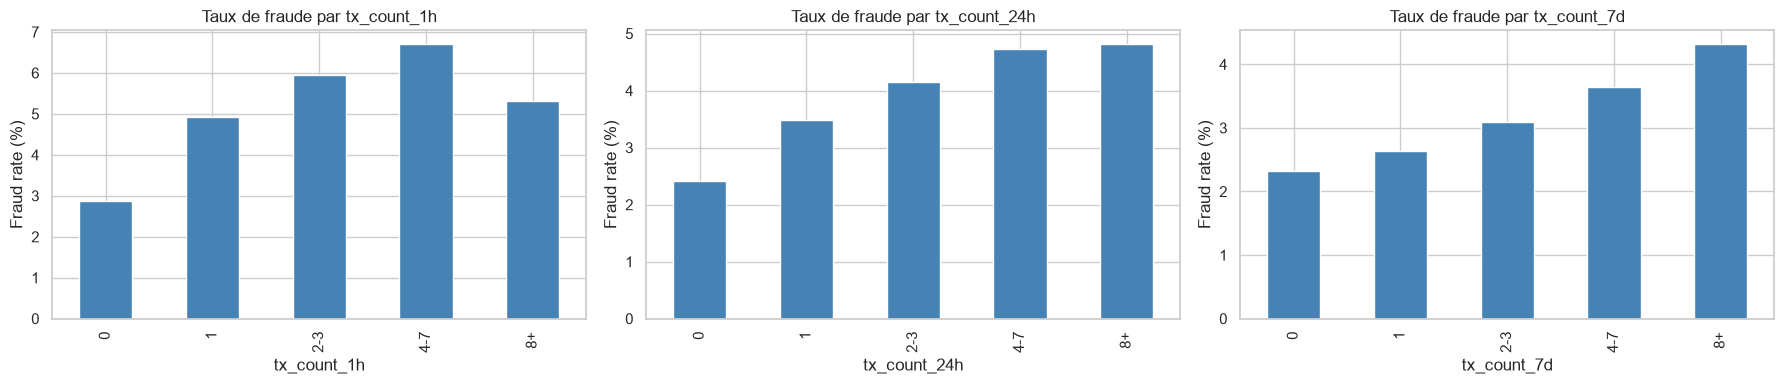

In [14]:
# Visualisation : taux de fraude selon les features de vélocité
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ['tx_count_1h', 'tx_count_24h', 'tx_count_7d']):
    binned = pd.cut(df[col], bins=[-0.1, 0, 1, 3, 7, np.inf],
                   labels=['0', '1', '2-3', '4-7', '8+'])
    fraud_rate = df.groupby(binned, observed=True)[TARGET].mean() * 100
    fraud_rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Taux de fraude par {col}')
    ax.set_ylabel('Fraud rate (%)')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'velocity_fraud_rate.png', dpi=150)
plt.show()

## 6. Sélection de features et préparation du pipeline

On filtre les colonnes avec plus de 95% de valeurs manquantes, qui n'apporteraient
aucune information utile au modèle.

In [15]:
# Colonnes exclues manuellement
exclude = {'TransactionID', TARGET, 'customer_proxy', 'tx_time_sec'}

# Filtrage des colonnes trop vides
high_missing = df.columns[df.isna().mean() > 0.95].tolist()
print(f'Colonnes avec >95% NaN supprimées : {len(high_missing)}')

all_features = [c for c in df.columns if c not in exclude and c not in high_missing]

X = df[all_features]
y = df[TARGET]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Features numériques  : {len(num_features)}')
print(f'Features catégorielles : {len(cat_features)}')
print(f'Total features       : {len(all_features)}')

Colonnes avec >95% NaN supprimées : 9
Features numériques  : 407
Features catégorielles : 29
Total features       : 436


## 7. Pipeline sklearn avec TimeSeriesSplit

### Pourquoi TimeSeriesSplit et pas KFold ?

Avec `KFold`, des données **futures** peuvent se retrouver dans le train et des données **passées**
dans le test. Le modèle "voit l'avenir", ce qui produit des métriques artificiellement optimistes.
C'est une fuite temporelle qui rendrait le modèle **inutilisable en production**.

Avec `TimeSeriesSplit`, chaque fold respecte l'ordre chronologique :
le train contient toujours des données **antérieures** au test.

In [16]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', min_frequency=0.01, sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
], remainder='drop')

phase1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

print('Pipeline phase 1 défini.')
print(phase1_pipeline)

Pipeline phase 1 défini.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['TransactionDT',
                                                   'TransactionAmt', 'card1',
                                                   'card2', 'card3', 'card5',
                                                   'addr1', 'addr2', 'dist1',
                                                   'dist2', 'C1', 'C2', 'C3',
                                                   'C4', 'C5', 'C6', 'C7', 'C8',
                                                   'C9', 'C10', 'C11', 'C12',
 

In [17]:
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

print('Cross-validation temporelle en cours (5 folds)...')

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X), start=1):
    X_tr_f = X.iloc[tr_idx]
    X_va_f = X.iloc[va_idx]
    y_tr_f = y.iloc[tr_idx]
    y_va_f = y.iloc[va_idx]

    t0 = time.time()
    phase1_pipeline.fit(X_tr_f, y_tr_f)
    fit_time = time.time() - t0

    y_pred_f  = phase1_pipeline.predict(X_va_f)
    y_proba_f = phase1_pipeline.predict_proba(X_va_f)[:, 1]

    cv_results.append({
        'fold':         fold,
        'train_size':   len(tr_idx),
        'valid_size':   len(va_idx),
        'accuracy':     accuracy_score(y_va_f, y_pred_f),
        'recall_fraud': recall_score(y_va_f, y_pred_f),
        'AUPRC':        average_precision_score(y_va_f, y_proba_f),
        'fit_time_sec': fit_time
    })
    print(f"  Fold {fold} | AUPRC={cv_results[-1]['AUPRC']:.4f} | Recall={cv_results[-1]['recall_fraud']:.4f} | Acc={cv_results[-1]['accuracy']:.4f}")

cv_df = pd.DataFrame(cv_results)
print('\n=== Résultats CV ===')
print(cv_df.to_string(index=False))

Cross-validation temporelle en cours (5 folds)...
  Fold 1 | AUPRC=0.4059 | Recall=0.2313 | Acc=0.9723
  Fold 2 | AUPRC=0.4226 | Recall=0.2945 | Acc=0.9657
  Fold 3 | AUPRC=0.4024 | Recall=0.2572 | Acc=0.9687


MemoryError: Unable to allocate 1.19 GiB for an array with shape (393694, 407) and data type int64

In [ ]:
# Visualisation des métriques par fold
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ['accuracy', 'recall_fraud', 'AUPRC']):
    ax.bar(cv_df['fold'], cv_df[metric], color='steelblue')
    ax.axhline(cv_df[metric].mean(), color='crimson', linestyle='--', label=f'Moyenne: {cv_df[metric].mean():.4f}')
    ax.set_title(metric)
    ax.set_xlabel('Fold')
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle('Métriques par fold — TimeSeriesSplit (LR baseline)', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_metrics_baseline.png', dpi=150)
plt.show()

print('=== Moyennes CV ===')
print(cv_df[['accuracy','recall_fraud','AUPRC']].mean().to_string())

In [ ]:
# Sauvegarde des résultats CV en artefact
cv_df.to_csv(ARTIFACTS_DIR / 'cv_results_phase1_baseline.csv', index=False)
print('Résultats sauvegardés dans artifacts/cv_results_phase1_baseline.csv')

## 8. Synthèse de la Phase 1

### Ce qui a été accompli

| Étape | Statut | Points clés |
|---|---|---|
| Chargement & fusion des données | ✅ | 590 540 lignes, 433 features |
| EDA — déséquilibre de classes | ✅ | ~3.5% fraude, ratio 1:28 |
| EDA — patterns temporels | ✅ | Voir figures/temporal_patterns.png |
| EDA — distribution des montants | ✅ | Fraudes : montants plus élevés en médiane |
| Baseline LR naïve | ✅ | Accuracy trompeuse vs AUPRC faible |
| Feature engineering temporel | ✅ | Vélocité 1h/24h/7j + déviation comportementale |
| Pipeline TimeSeriesSplit (5 folds) | ✅ | Validation chronologique stricte |

### Métriques baseline à retenir

_À compléter après exécution du notebook._

### Étape suivante — Phase 2

Le notebook `02_modelling.ipynb` comparera 5 stratégies de gestion du déséquilibre avec XGBoost :
baseline brut, pondération des classes, Random Undersampling, SMOTE, SMOTE+ENN.
Il abordera également les features graphe (NetworkX) et les GNN (GCN / GAT sur Elliptic).